precision@3 เฉลี่ย: 0.13
recall@3 เฉลี่ย: 0.50


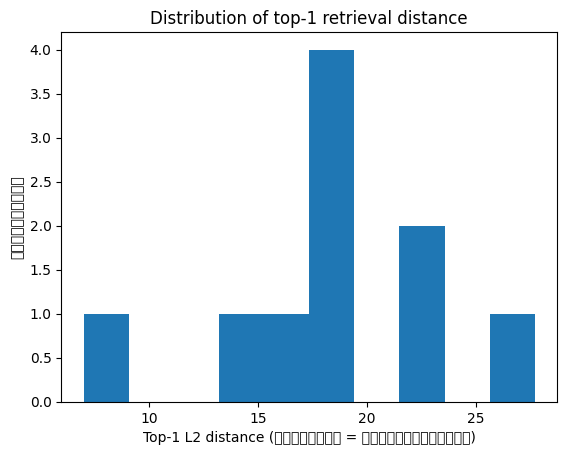

In [2]:
import matplotlib.pyplot as plt
from app import load_index

model, index, chunks = load_index()  # ไม่ต้องใช้ GOOGLE_API_KEY เพราะแค่ retrieval

ground_truth = [
    ("ร้านเปิดกี่โมง", [0]),
    ("เปิดวันไหนบ้าง", [0]),
    ("นมหมีฮอกไกโดราคาเท่าไหร่", [1]),
    ("นมโกโก้บราวนี่มีอะไรบ้าง", [1]),
    ("เมนูไหนมี gluten", [2]),
    ("แพ้ถั่วกินได้ไหม", [2]),
    ("ส่งได้ไกลแค่ไหน", [3]),
    ("มีเมนู vegan ไหม", [3]),
    ("มีที่จอดรถไหม", []),
    ("รับสมัครพนักงานไหม", []),
]

k = 3
results = []
for question, correct_idx in ground_truth:
    query_vec = model.encode([question], convert_to_numpy=True).astype("float32")
    distances, indices = index.search(query_vec, k)
    retrieved_idx = [int(i) for i in indices[0] if i != -1]
    results.append({
        "question": question,
        "retrieved_idx": retrieved_idx,
        "top1_distance": float(distances[0][0]),
        "correct_idx": correct_idx,
    })

def precision_at_k(retrieved, correct, k=3):
    return len(set(retrieved[:k]) & set(correct)) / k

precisions = [precision_at_k(r["retrieved_idx"], r["correct_idx"]) for r in results]
recalls = [
    len(set(r["retrieved_idx"]) & set(r["correct_idx"])) / len(r["correct_idx"])
    for r in results if r["correct_idx"]
]

print(f"precision@3 เฉลี่ย: {sum(precisions)/len(precisions):.2f}")
print(f"recall@3 เฉลี่ย: {sum(recalls)/len(recalls):.2f}")

scores = [r["top1_distance"] for r in results]
plt.hist(scores, bins=10)
plt.xlabel("Top-1 L2 distance (ยิ่งน้อย = ยิ่งใกล้เคียง)")
plt.ylabel("จำนวนคำถาม")
plt.title("Distribution of top-1 retrieval distance")
plt.show()